# Hourly community-energy analysis

Carga `evaluation_agent_states.csv` de cada semilla, agrega por hora y grafica las cinco series:
**generación, demanda, P2P, importación, exportación**.

Las cinco series se derivan del propio CSV (no se necesita el JSON de perfiles):

- `generation` y `demand` se reconstruyen de las columnas `cap` y `role_vec`:
  - `generation = Σ cap[i]` para los agentes con `role_vec[i] == +1`
  - `demand     = Σ cap[i]` para los agentes con `role_vec[i] == -1`
- `p2p`, `import` y `export` salen de `total_p2p`, `total_import`, `total_export`.

**Promedio sobre los 4 sub-pasos** dentro de cada hora — los sub-pasos son la ventana donde los agentes estabilizan acciones, no transacciones independientes.

Dos modos: **promedio entre semillas** o **una sola** semilla/run.

Asume que `plot_hourly_energy.py` está en la raíz del proyecto, junto al notebook.


## Setup


In [54]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd

from plot_hourly_energy import (
    plot_hourly_energy,
    plot_hourly_energy_overlay,
    find_runs,
    aggregate_runs,
    plot_cumulative_rewards,
    aggregate_csv_per_seed,
)




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

### Path
Editá esta constante una sola vez. El resto del notebook la usa.


In [56]:
SCENARIO_DIR_DESC = "../exp_results_repro/descentralized_exp"
SCENARIO1_ISGT = "../exp_results_repro/scenario1_v2_ISGT"
SCENARIO2_ISGT = "../exp_results_repro/scenario2_v2_ISGT"
SCENARIO3_ISGT = "../exp_results_repro/scenario3_v2_ISGT"


## Modo 1 — Promedio sobre todas las semillas

Si no se pasa `seed`, agrega todos los runs encontrados.
La función devuelve el DataFrame agregado y muestra el gráfico inline.


## Scenario 1 ISGT

,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.043036,0.016964,5.696964
1.0,6.57,0.12,0.084694,0.035306,6.485306
2.0,6.88,0.10,0.070403,0.029597,6.809597
3.0,6.90,0.10,0.070549,0.029451,6.829451
4.0,6.14,0.10,0.071820,0.028180,6.068180


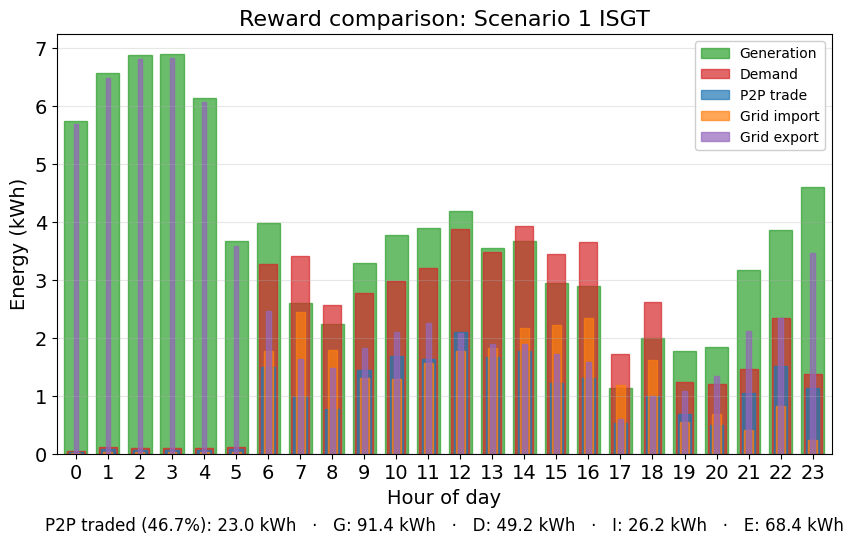

In [39]:
df_avg = plot_hourly_energy_overlay(SCENARIO1_ISGT, title="Reward comparison: Scenario 1 ISGT", figsize=(10, 6))
df_avg.head()


,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.048784,0.011216,5.691216
1.0,6.57,0.12,0.103105,0.016895,6.466895
2.0,6.88,0.10,0.086195,0.013805,6.793804
3.0,6.90,0.10,0.086339,0.013661,6.813661
4.0,6.14,0.10,0.081885,0.018115,6.058115


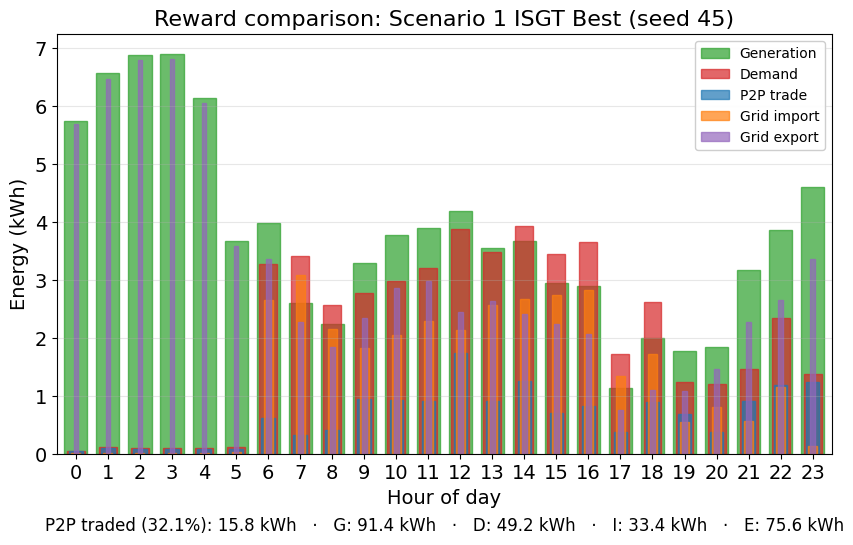

In [40]:
df_avg = plot_hourly_energy_overlay(SCENARIO1_ISGT, title="Reward comparison: Scenario 1 ISGT Best (seed 45)", figsize=(10, 6), seed=45)
df_avg.head()

,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.049610,0.010390,5.690390
1.0,6.57,0.12,0.089778,0.030222,6.480222
2.0,6.88,0.10,0.073041,0.026959,6.806958
3.0,6.90,0.10,0.073608,0.026392,6.826392
4.0,6.14,0.10,0.083137,0.016863,6.056863


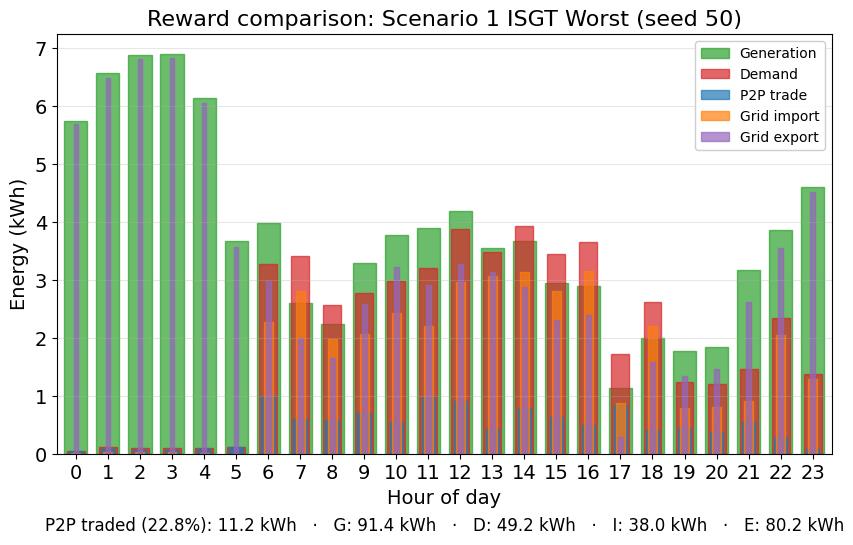

In [47]:
df_avg = plot_hourly_energy_overlay(SCENARIO1_ISGT, title="Reward comparison: Scenario 1 ISGT Worst (seed 50)", figsize=(10, 6), seed=50)
df_avg.head()

## Scenario 2 ISGT

,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.049772,0.010228,5.690228
1.0,6.57,0.12,0.098988,0.021012,6.471012
2.0,6.88,0.10,0.081989,0.018011,6.798011
3.0,6.90,0.10,0.082143,0.017857,6.817857
4.0,6.14,0.10,0.082807,0.017193,6.057193


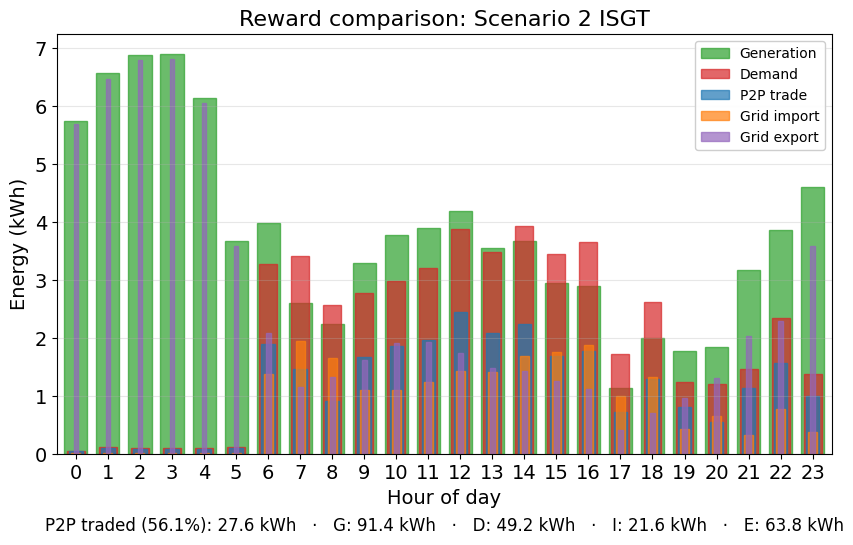

In [41]:
df_avg = plot_hourly_energy_overlay(SCENARIO2_ISGT, title="Reward comparison: Scenario 2 ISGT", figsize=(10, 6))
df_avg.head()


,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.054906,0.005094,5.685094
1.0,6.57,0.12,0.109794,0.010206,6.460206
2.0,6.88,0.10,0.091641,0.008359,6.788359
3.0,6.90,0.10,0.091658,0.008342,6.808342
4.0,6.14,0.10,0.091749,0.008251,6.048251


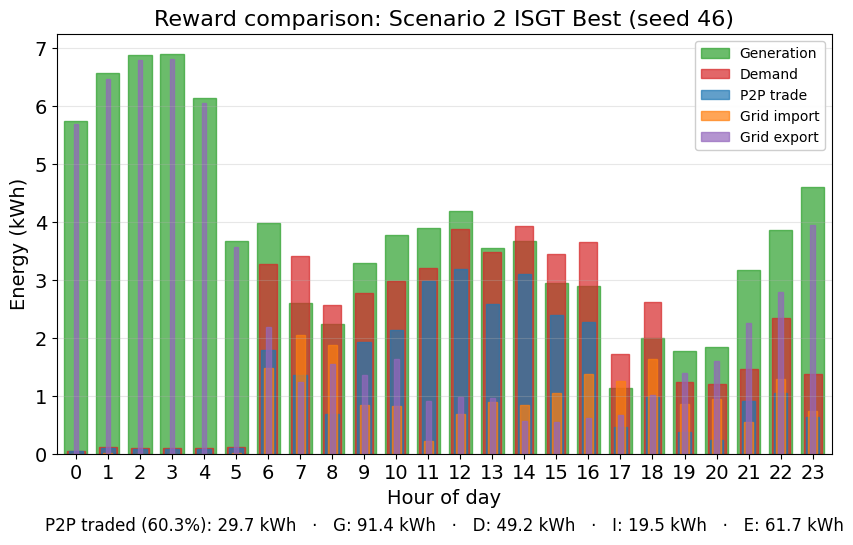

In [44]:
df_avg = plot_hourly_energy_overlay(SCENARIO2_ISGT, title="Reward comparison: Scenario 2 ISGT Best (seed 46)", figsize=(10, 6), seed=46)
df_avg.head()

,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.06,0.0,5.68
1.0,6.57,0.12,0.12,0.0,6.45
2.0,6.88,0.10,0.10,0.0,6.78
3.0,6.90,0.10,0.10,0.0,6.80
4.0,6.14,0.10,0.10,0.0,6.04


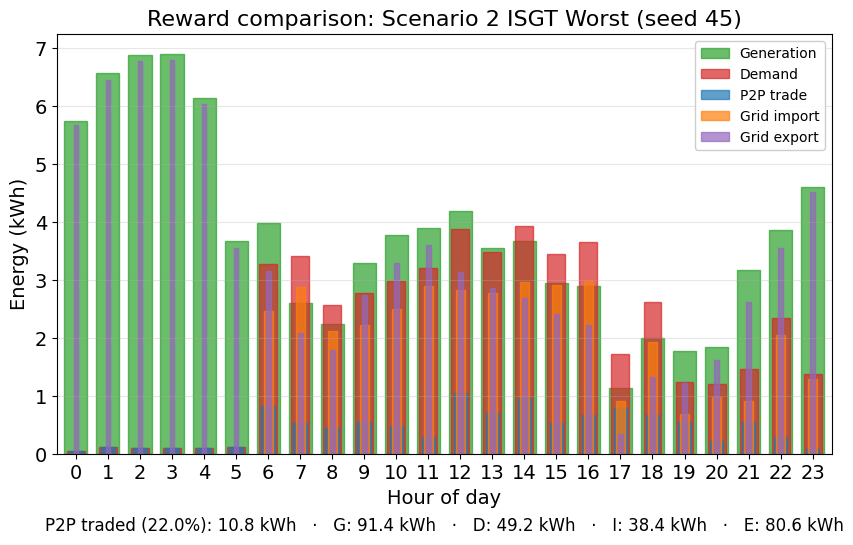

In [48]:
df_avg = plot_hourly_energy_overlay(SCENARIO2_ISGT, title="Reward comparison: Scenario 2 ISGT Worst (seed 45)", figsize=(10, 6), seed=45)
df_avg.head()

## Scenario 3 ISGT

,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.047106,0.012894,5.692894
1.0,6.57,0.12,0.093634,0.026366,6.476366
2.0,6.88,0.10,0.078371,0.021629,6.801629
3.0,6.90,0.10,0.078843,0.021157,6.821157
4.0,6.14,0.10,0.079704,0.020296,6.060296


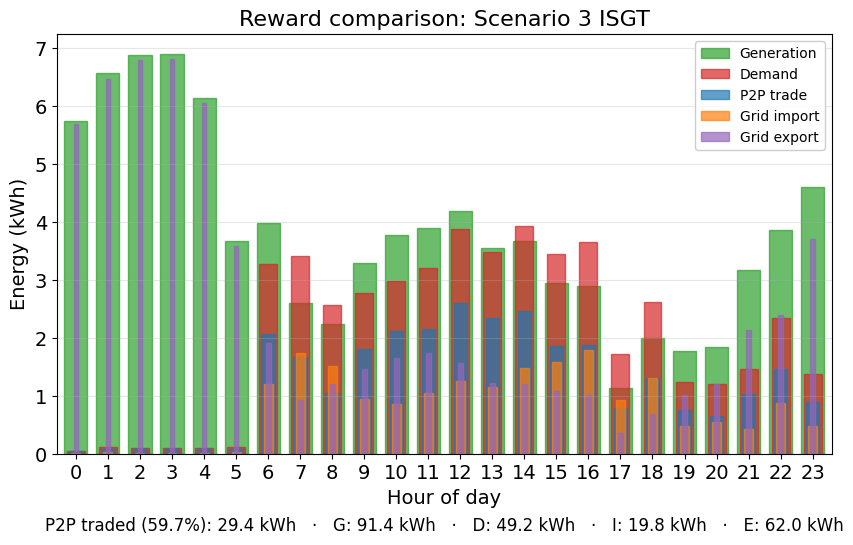

In [42]:
df_avg = plot_hourly_energy_overlay(SCENARIO3_ISGT, title="Reward comparison: Scenario 3 ISGT", figsize=(10, 6))
df_avg.head()


,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.060000,0.000000,5.680000
1.0,6.57,0.12,0.120000,0.000000,6.450000
2.0,6.88,0.10,0.099867,0.000133,6.780133
3.0,6.90,0.10,0.099765,0.000235,6.800235
4.0,6.14,0.10,0.100000,0.000000,6.040000


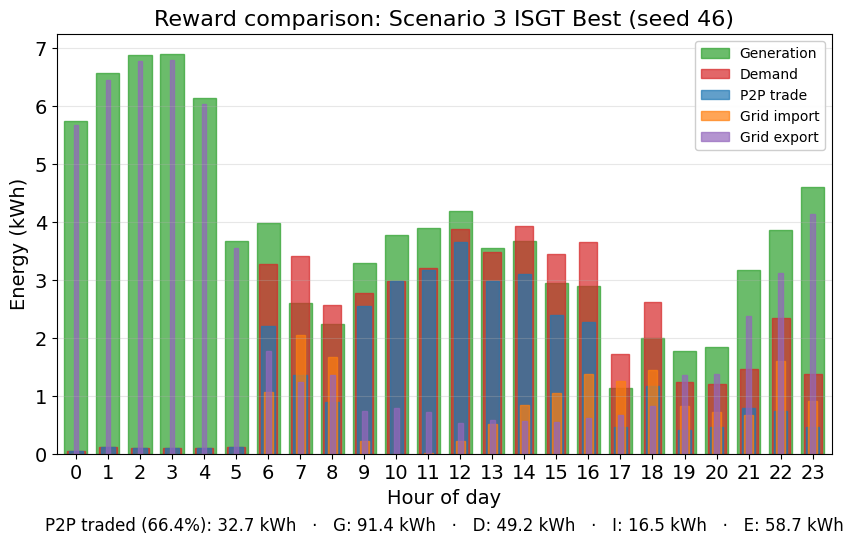

In [45]:
df_avg = plot_hourly_energy_overlay(SCENARIO3_ISGT, title="Reward comparison: Scenario 3 ISGT Best (seed 46)", figsize=(10, 6), seed=46)
df_avg.head()

,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.06,0.0,5.68
1.0,6.57,0.12,0.12,0.0,6.45
2.0,6.88,0.10,0.10,0.0,6.78
3.0,6.90,0.10,0.10,0.0,6.80
4.0,6.14,0.10,0.10,0.0,6.04


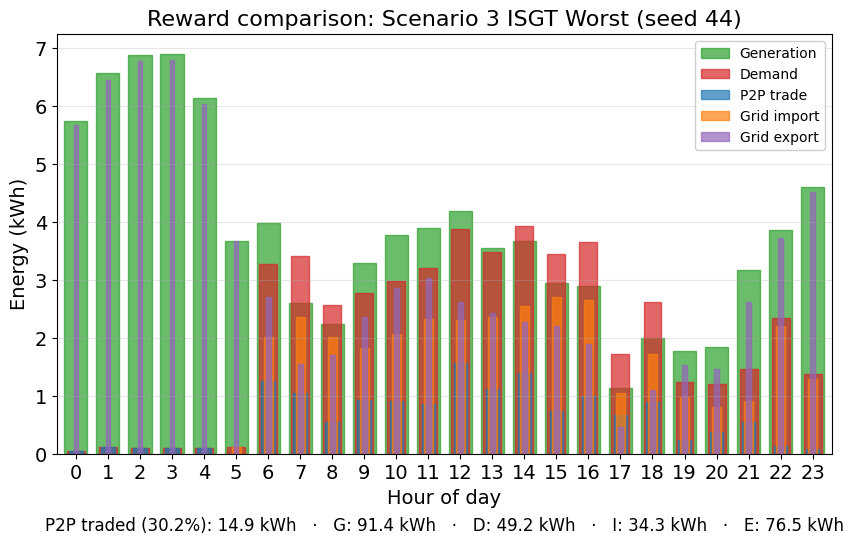

In [50]:
df_avg = plot_hourly_energy_overlay(SCENARIO3_ISGT, title="Reward comparison: Scenario 3 ISGT Worst (seed 44)", figsize=(10, 6), seed=44)
df_avg.head()

## Scenario Descentralized

,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.053343,0.006657,5.686657
1.0,6.57,0.12,0.106815,0.013185,6.463185
2.0,6.88,0.10,0.088580,0.011420,6.791420
3.0,6.90,0.10,0.088342,0.011658,6.811658
4.0,6.14,0.10,0.088115,0.011885,6.051885


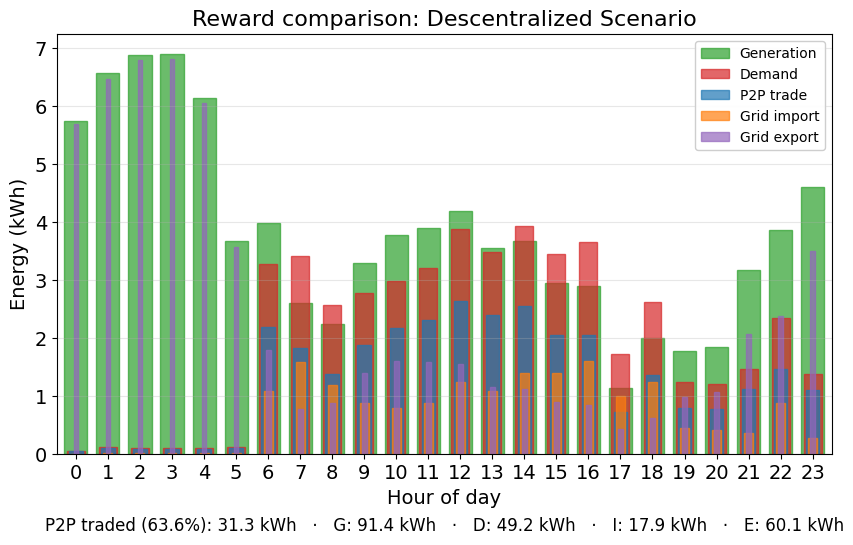

In [43]:
df_avg = plot_hourly_energy_overlay(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario", figsize=(10, 6))
df_avg.head()


,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.06,0.0,5.68
1.0,6.57,0.12,0.12,0.0,6.45
2.0,6.88,0.10,0.10,0.0,6.78
3.0,6.90,0.10,0.10,0.0,6.80
4.0,6.14,0.10,0.10,0.0,6.04


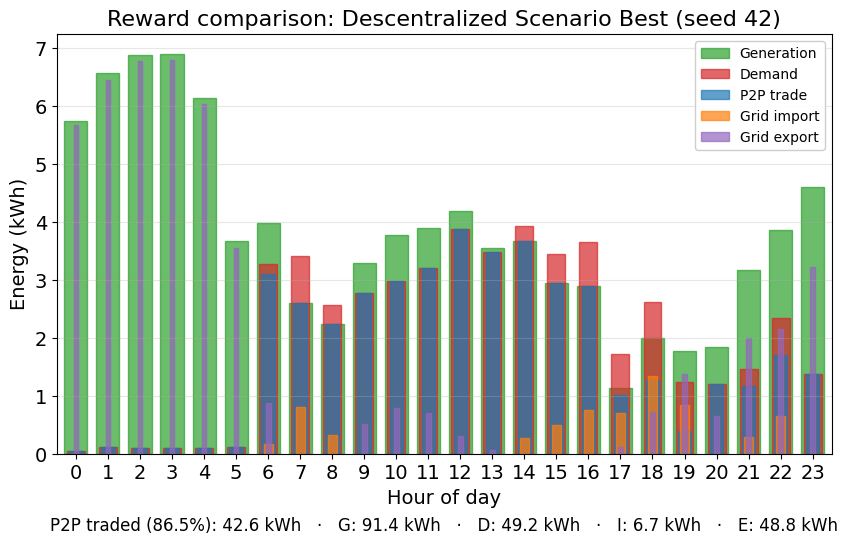

In [46]:
df_avg = plot_hourly_energy_overlay(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario Best (seed 42)", figsize=(10, 6), seed=42)
df_avg.head()

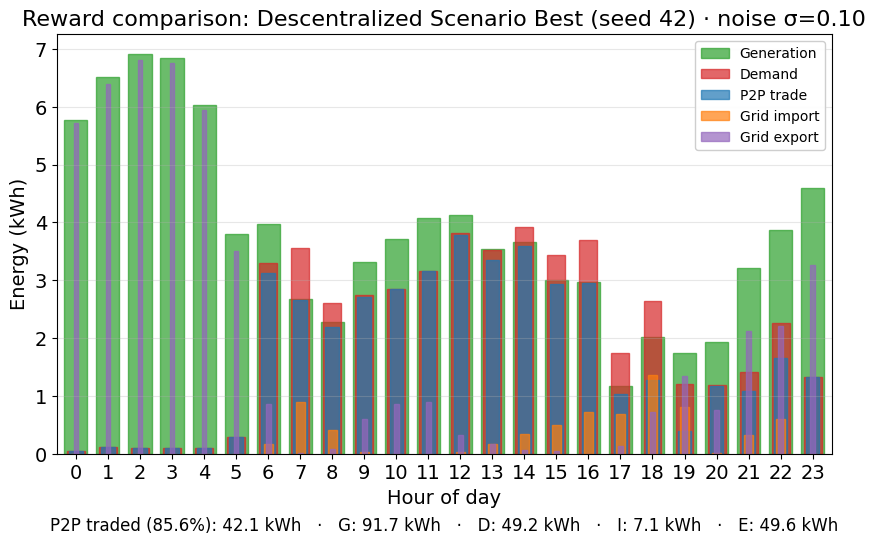

In [66]:
df_avg = plot_hourly_energy_overlay(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario Best (seed 42)", figsize=(10, 6), noise_std=0.10, seed=42)

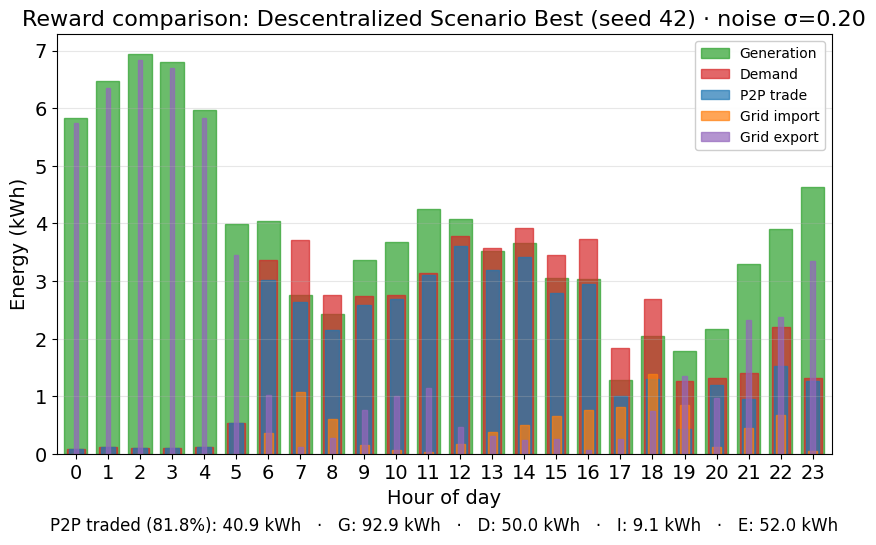

In [69]:
df_avg = plot_hourly_energy_overlay(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario Best (seed 42)", figsize=(10, 6), noise_std=0.20, seed=42)

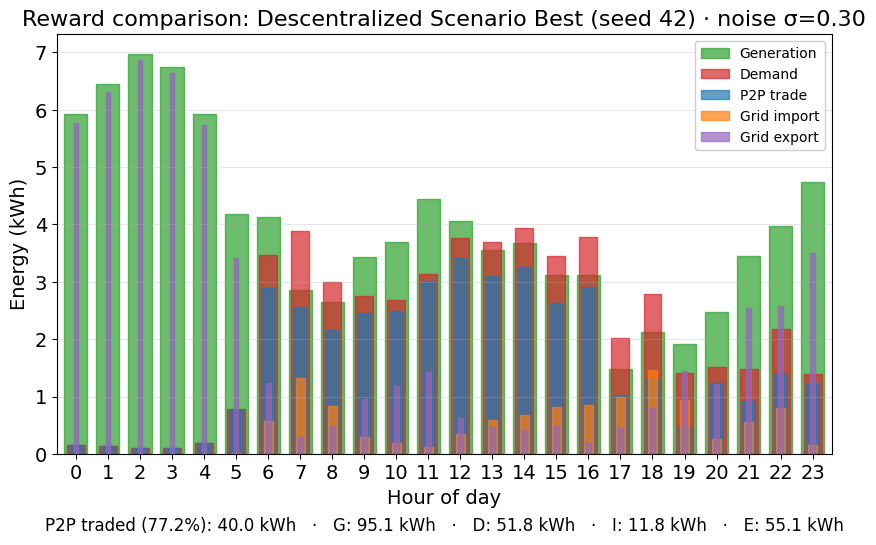

In [71]:
df_avg = plot_hourly_energy_overlay(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario Best (seed 42)", figsize=(10, 6), noise_std=0.30, seed=42)

,generation,demand,p2p,imp,exp
hour_index,,,,,
0.0,5.74,0.06,0.011789,0.048211,5.728211
1.0,6.57,0.12,0.024546,0.095454,6.545454
2.0,6.88,0.10,0.019578,0.080422,6.860422
3.0,6.90,0.10,0.019096,0.080904,6.880904
4.0,6.14,0.10,0.018625,0.081375,6.121375


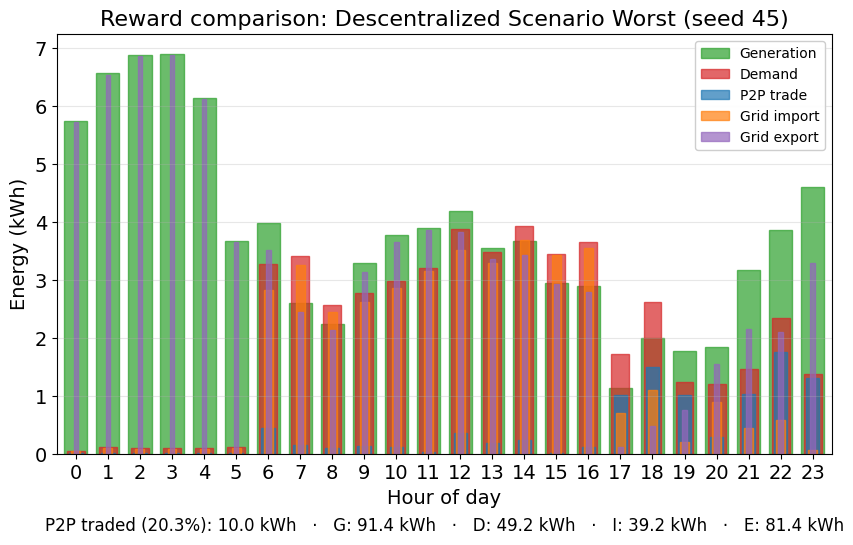

In [52]:
df_avg = plot_hourly_energy_overlay(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario Worst (seed 45)", figsize=(10, 6), seed=45)
df_avg.head()

# GINI Coefficient

## Scenario 1 ISGT


[plot_cumulative_rewards] scenario1_v2_ISGT
  Aggregate (cross-seed mean vector):
    Jain  = 0.6121    LossN = 16.67%    LossV = 0.0037    Gini = 0.4313
  Per-seed:
    seed/run                                Jain    LossN    LossV     Gini
    -----------------------------------  -------  -------  -------  -------
    energy_market_training_seed42_run1    0.6065   0.00%   0.0000   0.4456
    energy_market_training_seed43_run2    0.4968  16.67%   0.0038   0.5254
    energy_market_training_seed44_run3    0.4717  16.67%   0.0288   0.5000
    energy_market_training_seed45_run4    0.8321   0.00%   0.0000   0.2389
    energy_market_training_seed46_run5    0.4471  16.67%   0.0674   0.5484
    energy_market_training_seed47_run6    0.5116  16.67%   0.0244   0.4964
    energy_market_training_seed48_run7    0.4902   0.00%   0.0000   0.5332
    energy_market_training_seed49_run8    0.7306  16.67%   0.1566   0.3401
    energy_market_training_seed50_run9    0.7404  33.33%   0.3682   0.3285
    en

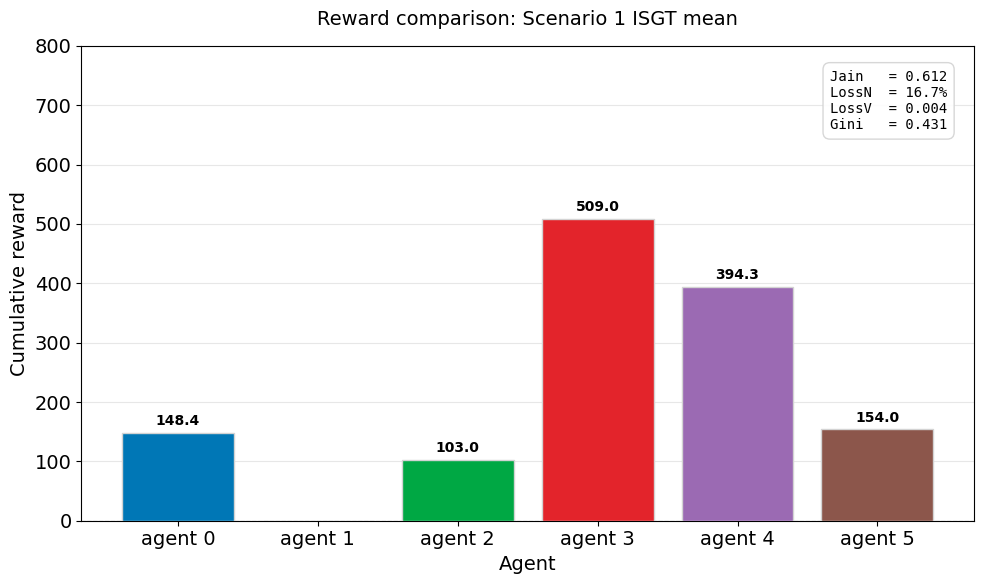

In [17]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO1_ISGT, title="Reward comparison: Scenario 1 ISGT mean", figsize=(10, 6))
plt.show()

### Muy buena

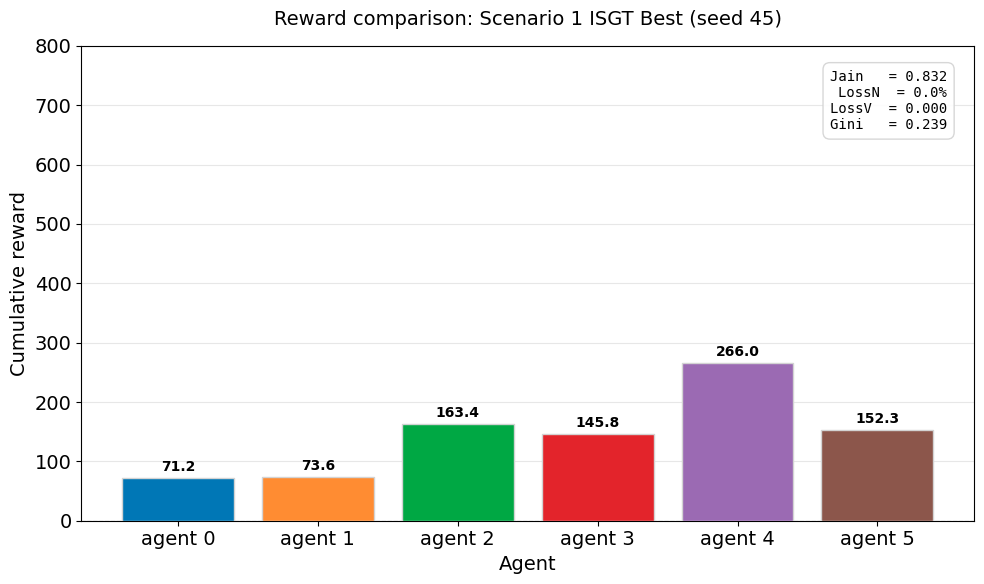

In [18]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO1_ISGT, title="Reward comparison: Scenario 1 ISGT Best (seed 45)", figsize=(10, 6), seed=45)
plt.show()
# 45

### Muy mala 

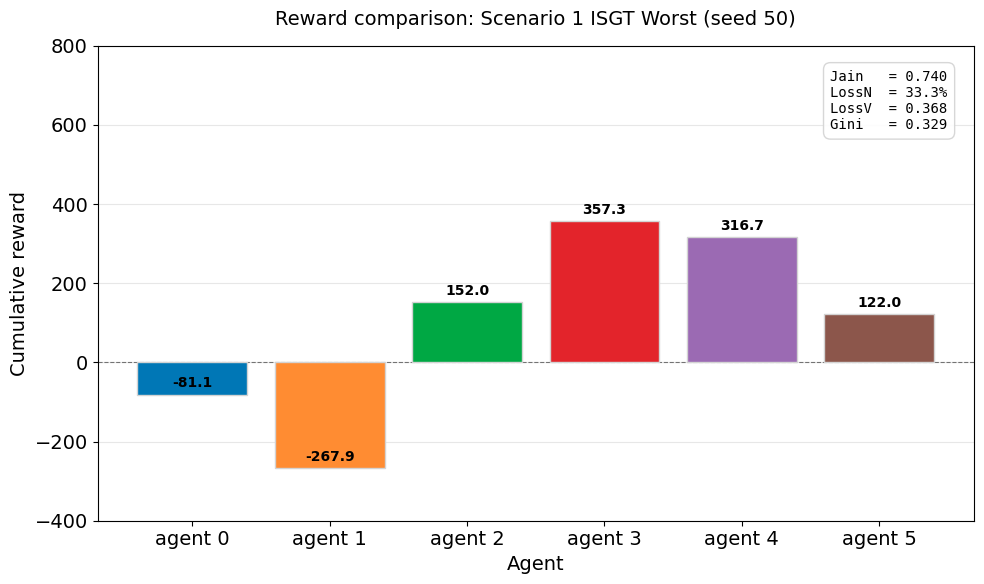

In [19]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO1_ISGT, title="Reward comparison: Scenario 1 ISGT Worst (seed 50)", figsize=(10, 6), seed=50, ylim=(-400, 800))
plt.show()

## Scenario 2 ISGT


[plot_cumulative_rewards] scenario2_v2_ISGT
  Aggregate (cross-seed mean vector):
    Jain  = 0.7310    LossN = 0.00%    LossV = 0.0000    Gini = 0.3352
  Per-seed:
    seed/run                                Jain    LossN    LossV     Gini
    -----------------------------------  -------  -------  -------  -------
    energy_market_training_seed42_run1    0.7442  16.67%   0.0396   0.3163
    energy_market_training_seed43_run2    0.5511  16.67%   0.0146   0.4703
    energy_market_training_seed44_run3    0.6071   0.00%   0.0000   0.4440
    energy_market_training_seed45_run4    0.6263  33.33%   0.3214   0.4300
    energy_market_training_seed46_run5    0.8273   0.00%   0.0000   0.2588
    energy_market_training_seed47_run6    0.7941  16.67%   0.0521   0.2670
    energy_market_training_seed48_run7    0.7350   0.00%   0.0000   0.3110
    energy_market_training_seed49_run8    0.4667   0.00%   0.0000   0.4869
    energy_market_training_seed50_run9    0.6813   0.00%   0.0000   0.3746
    ene

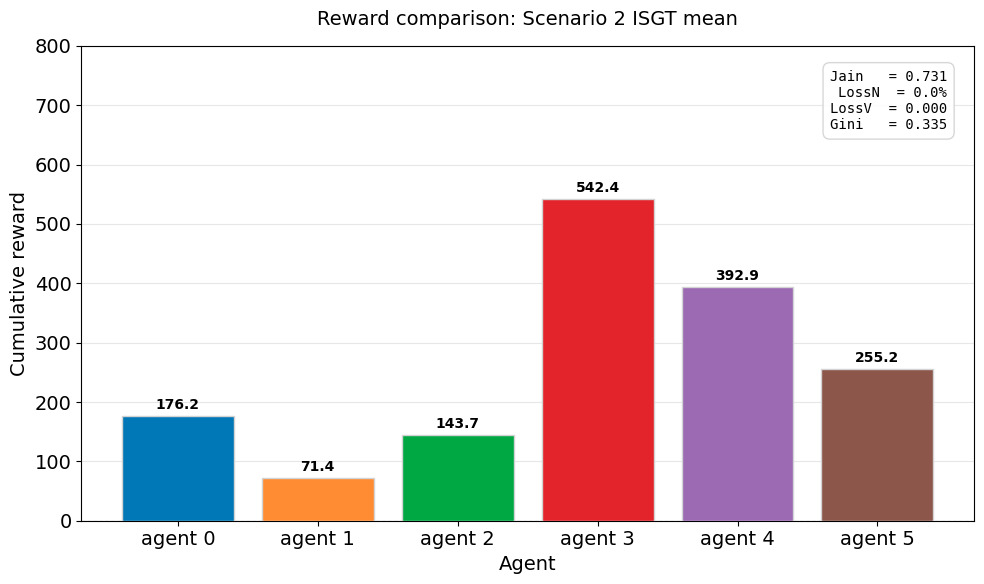

In [20]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO2_ISGT, title="Reward comparison: Scenario 2 ISGT mean", figsize=(10, 6))
plt.show()

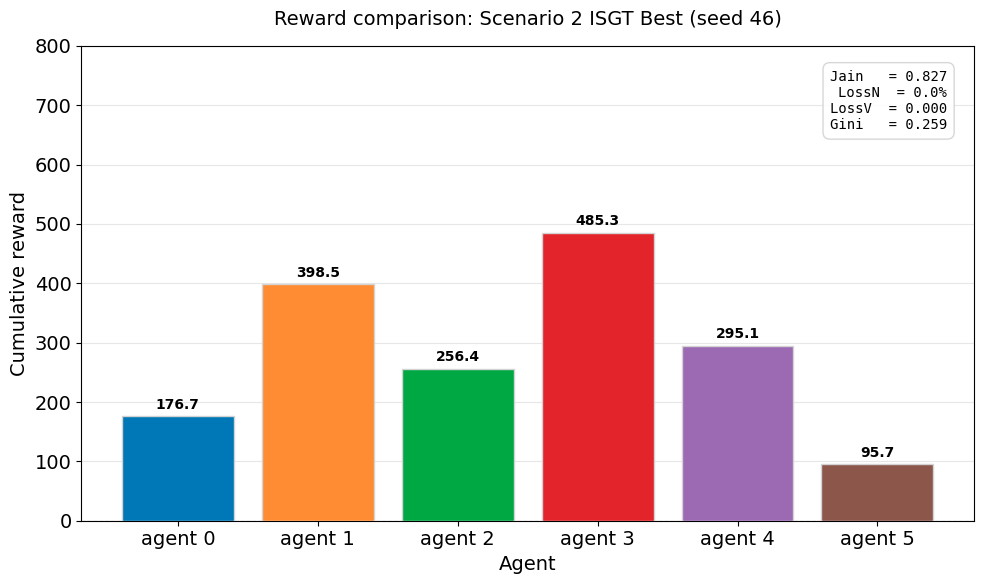

In [21]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO2_ISGT, title="Reward comparison: Scenario 2 ISGT Best (seed 46)", figsize=(10, 6), seed=46)
plt.show()

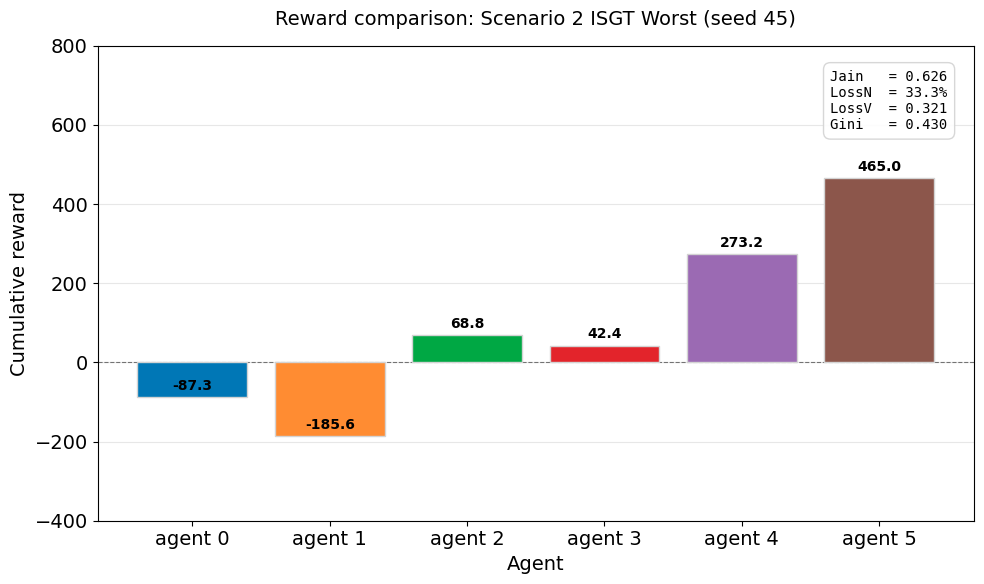

In [22]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO2_ISGT, title="Reward comparison: Scenario 2 ISGT Worst (seed 45)", figsize=(10, 6), seed=45, ylim=(-400, 800))
plt.show()

## Scenario 3 ISGT


[plot_cumulative_rewards] scenario3_v2_ISGT
  Aggregate (cross-seed mean vector):
    Jain  = 0.6527    LossN = 0.00%    LossV = 0.0000    Gini = 0.3992
  Per-seed:
    seed/run                                Jain    LossN    LossV     Gini
    -----------------------------------  -------  -------  -------  -------
    energy_market_training_seed42_run1    0.6723  16.67%   0.0609   0.3739
    energy_market_training_seed43_run2    0.5096  16.67%   0.0196   0.4923
    energy_market_training_seed44_run3    0.6536  33.33%   0.2467   0.4080
    energy_market_training_seed45_run4    0.6905  16.67%   0.0599   0.3649
    energy_market_training_seed46_run5    0.7980   0.00%   0.0000   0.2752
    energy_market_training_seed47_run6    0.7923  16.67%   0.1016   0.2695
    energy_market_training_seed48_run7    0.5975   0.00%   0.0000   0.4233
    energy_market_training_seed49_run8    0.3733   0.00%   0.0000   0.5885
    energy_market_training_seed50_run9    0.6586   0.00%   0.0000   0.3913
    ene

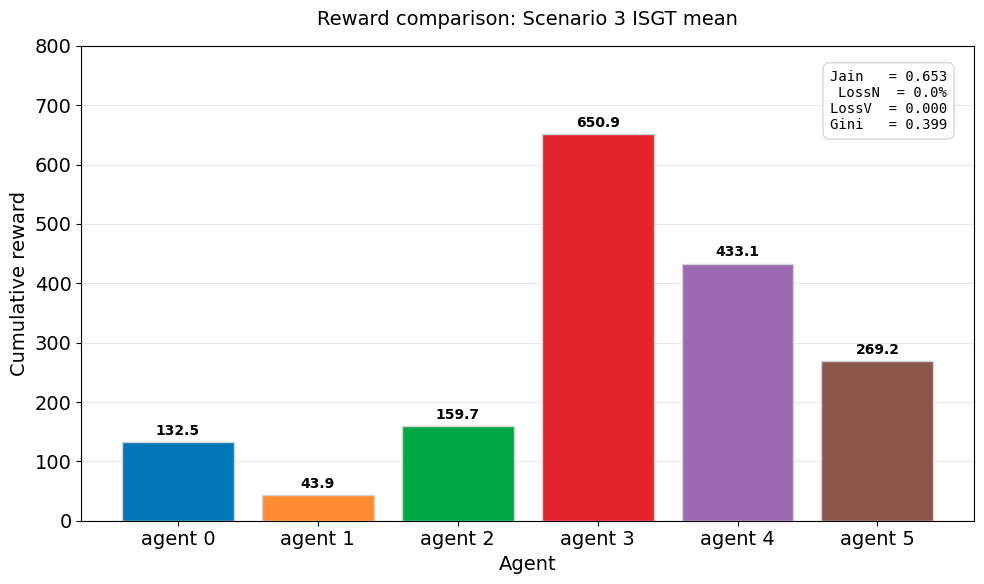

In [23]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO3_ISGT, title="Reward comparison: Scenario 3 ISGT mean", figsize=(10, 6))
plt.show()

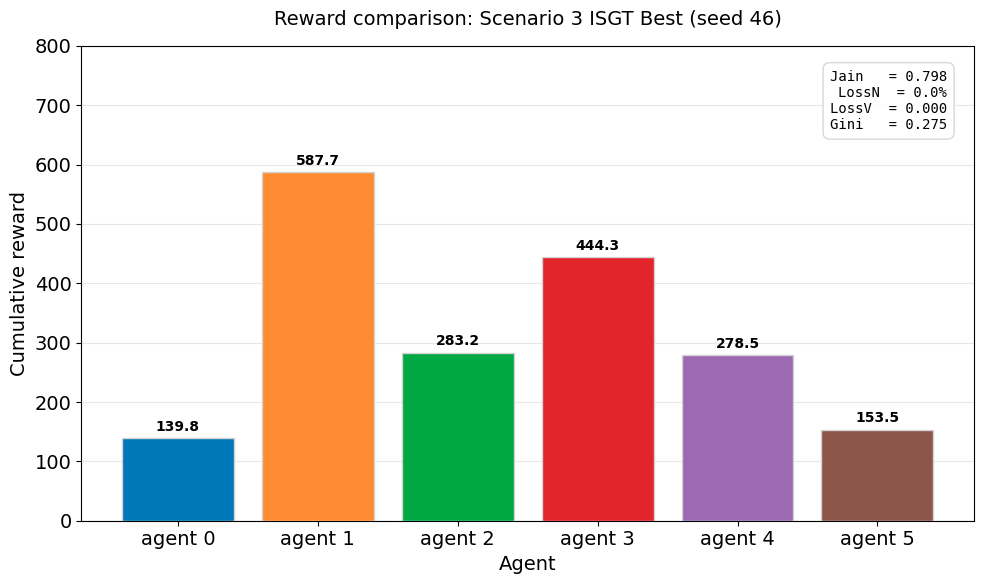

In [24]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO3_ISGT, title="Reward comparison: Scenario 3 ISGT Best (seed 46)", figsize=(10, 6), seed=46)
plt.show()

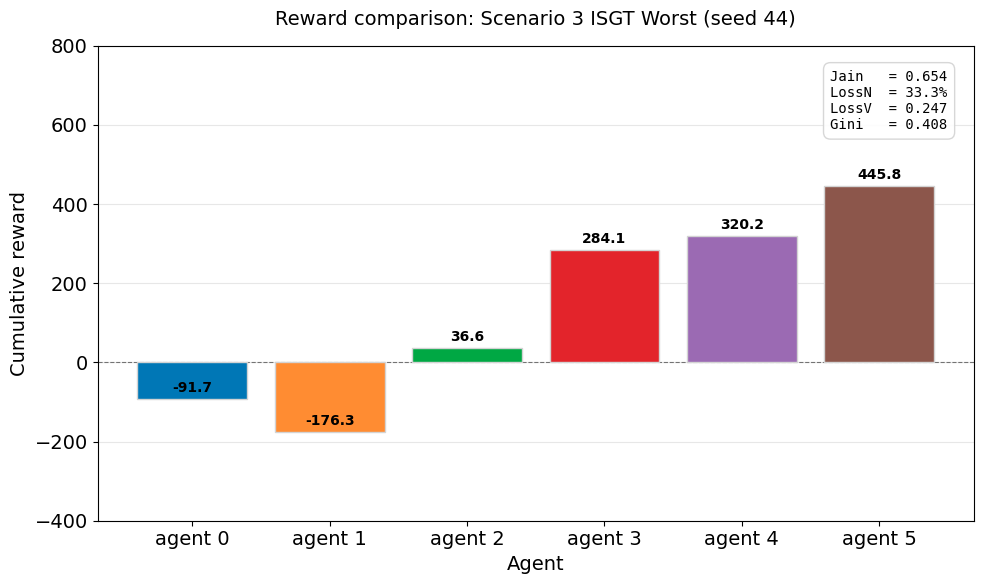

In [25]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO3_ISGT, title="Reward comparison: Scenario 3 ISGT Worst (seed 44)", figsize=(10, 6), seed=44, ylim=(-400, 800))
plt.show()

# Scenario 4 Descentralized


[plot_cumulative_rewards] descentralized_exp
  Aggregate (cross-seed mean vector):
    Jain  = 0.6560    LossN = 0.00%    LossV = 0.0000    Gini = 0.3918
  Per-seed:
    seed/run                                Jain    LossN    LossV     Gini
    -----------------------------------  -------  -------  -------  -------
    energy_market_training_seed42_run1    0.7967   0.00%   0.0000   0.2780
    energy_market_training_seed43_run2    0.6922  16.67%   0.1501   0.3616
    energy_market_training_seed44_run3    0.7800   0.00%   0.0000   0.2838
    energy_market_training_seed45_run4    0.7353  33.33%   0.2722   0.3285
    energy_market_training_seed46_run5    0.6876  33.33%   0.1232   0.3614
    energy_market_training_seed47_run6    0.4583  16.67%   0.0248   0.5299
    energy_market_training_seed48_run7    0.4118  33.33%   0.1551   0.5970
    energy_market_training_seed49_run8    0.6269   0.00%   0.0000   0.4173
    energy_market_training_seed50_run9    0.7262   0.00%   0.0000   0.3390
    en

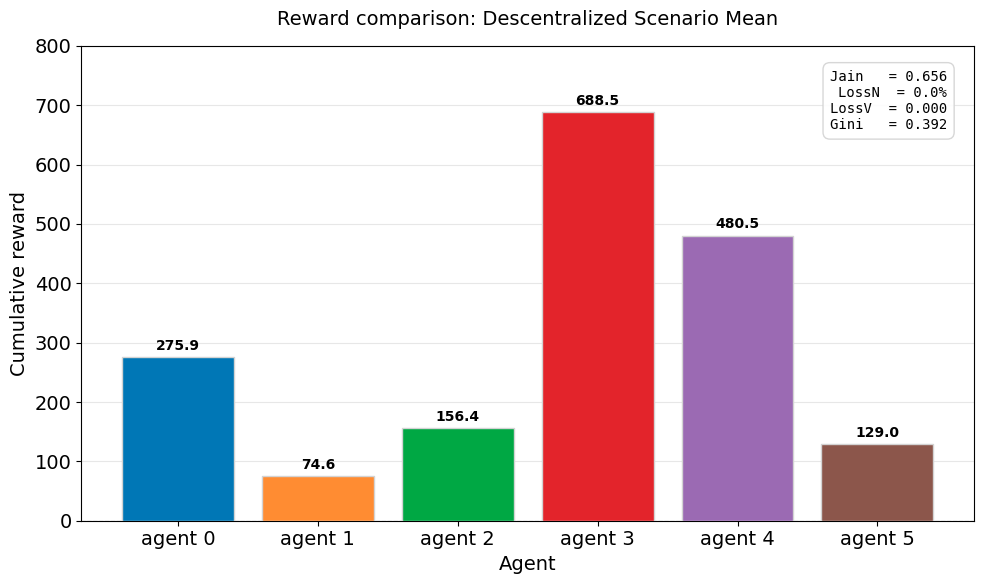

In [26]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario Mean", figsize=(10, 6))
plt.show()

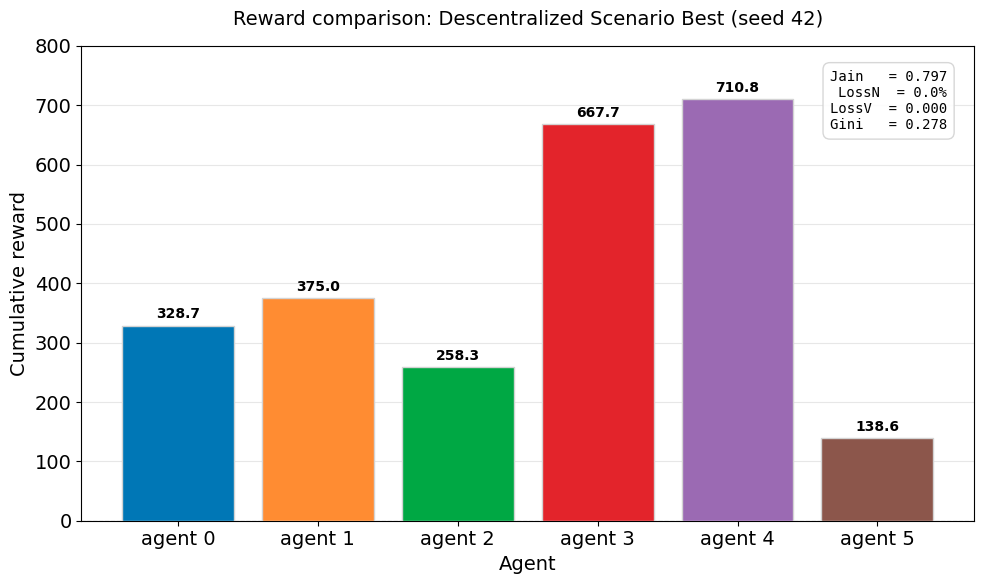

In [27]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario Best (seed 42)", figsize=(10, 6), seed=42)
plt.show()

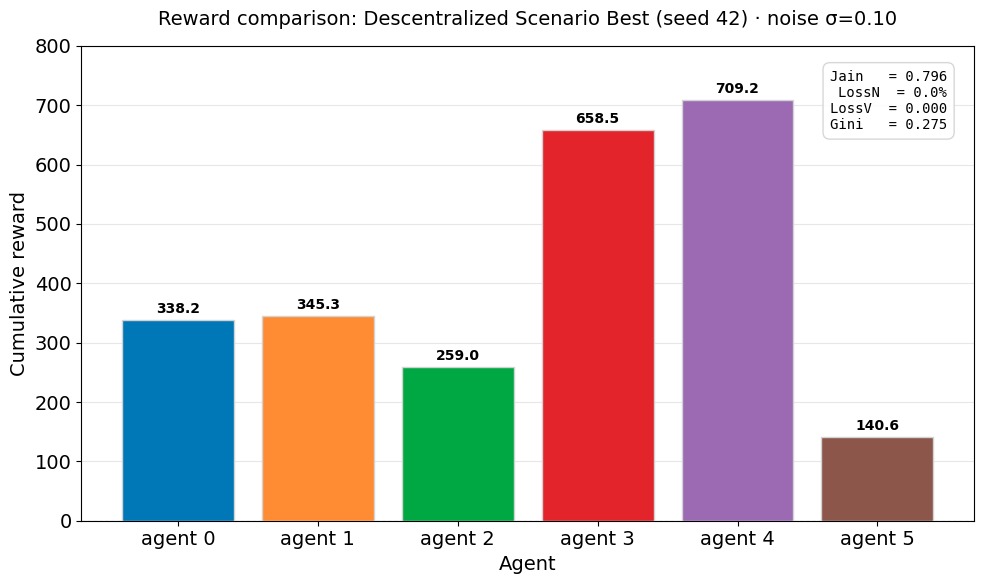

In [62]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario Best (seed 42)", figsize=(10, 6), seed=42, noise_std=0.10)
plt.show()

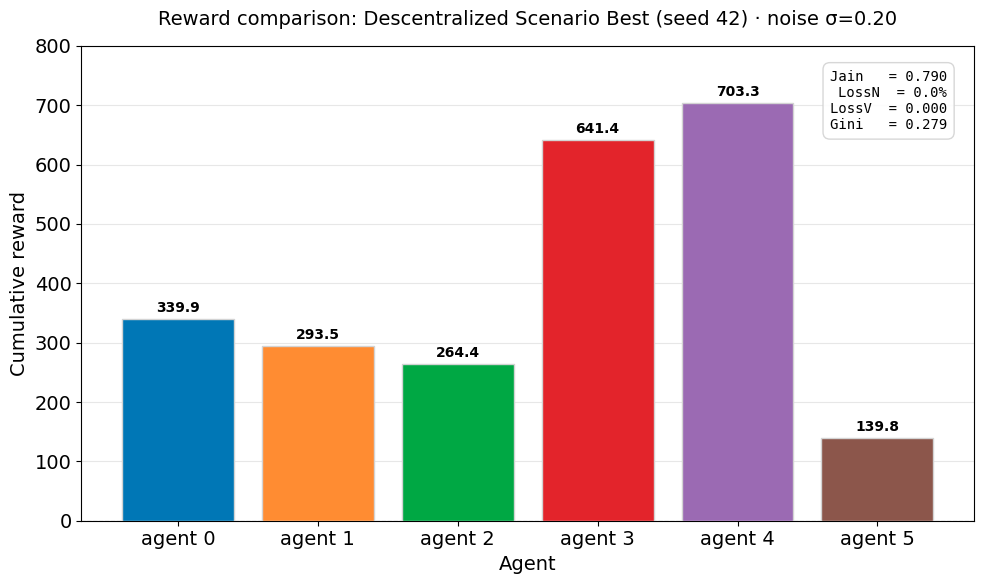

In [63]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario Best (seed 42)", figsize=(10, 6), seed=42, noise_std=0.20)
plt.show()

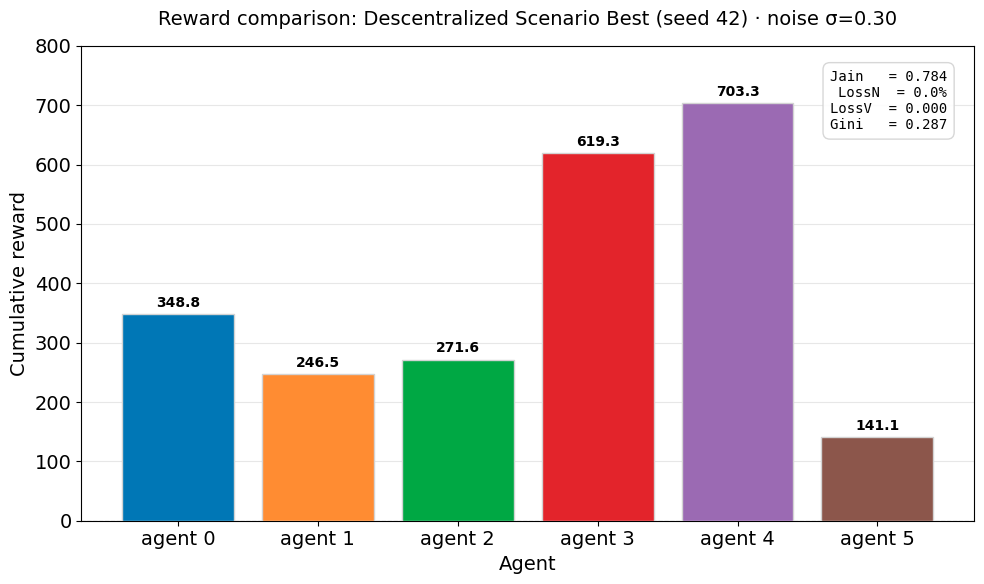

In [67]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario Best (seed 42)", figsize=(10, 6), seed=42, noise_std=0.30)
plt.show()

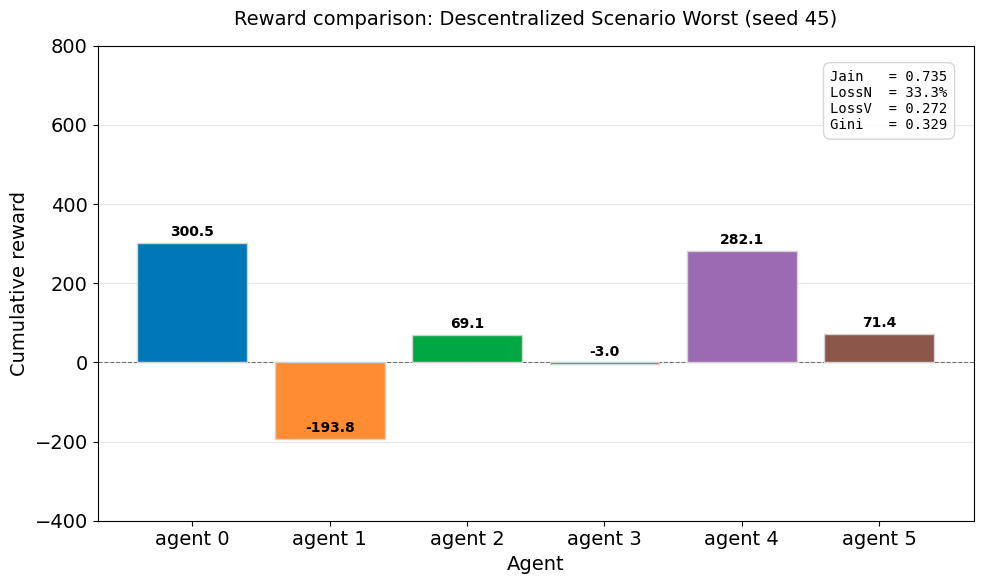

In [28]:
fig, ax, _ = plot_cumulative_rewards(SCENARIO_DIR_DESC, title="Reward comparison: Descentralized Scenario Worst (seed 45)", figsize=(10, 6), seed=45, ylim=(-400, 800) )
plt.show()